In [1]:
!pip install lightning --quiet

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning.pytorch as pl
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from torchmetrics.classification import Accuracy
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint

In [19]:
# --- Multi-Head Self-Attention (MHSA) Module ---
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert (
            embed_dim % num_heads == 0
        ), "Embedding dimension must be divisible by number of heads"
        
        # Query, Key, Value matrices
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim) # for final projection of the concated attentions
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, x):
        B, N, C = x.shape  # Batch size, Sequence length, Embedding dimension
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, 
                                  self.head_dim).permute(2, 0, 3, 1, 4) # rearranges the tensor dimensions to [3, B, num_heads, N, head_dim].
        # remember that the shape is 3*dim and we need to dive it to heads numbers and their QKV
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        # Scaled Dot-Product Attention
        attn_scores = (q @ k.transpose(-2, -1)) / self.head_dim ** 0.5
        attn = F.softmax(attn_scores, dim=-1)
        
        out = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(out)

# --- Transformer Encoder Block ---
class TransformerEncoderBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.layernorm1 = nn.LayerNorm(embed_dim)
        self.layernorm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout),
        )
        
    def forward(self, x):
        x = x + self.mha(self.layernorm1(x))  # Residual connection
        x = x + self.mlp(self.layernorm2(x))  # Residual connection
        return x

# --- Patch Embedding Layer ---
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
        
    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)  # [B, C, H, W] -> [B, N, D=numofpathces]
        return x

# --- Vision Transformer (ViT) Model ---
class VisionTransformer(nn.Module):
    def __init__(
        self, img_size=32, patch_size=8, in_channels=3, num_classes=10,
        embed_dim=512, num_heads=4, depth=6, mlp_dim=256, dropout=0.1
    ):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim)) # Tokens for pathces
        self.pos_embed = nn.Parameter(torch.zeros(1, self.patch_embed.num_patches + 1, embed_dim)) #positional embeding
        self.dropout = nn.Dropout(dropout)
        self._initialize_weights()
        self.transformer = nn.Sequential(
            *[TransformerEncoderBlock(embed_dim, num_heads, mlp_dim, dropout) for _ in range(depth)]
        )
        
        self.layernorm = nn.LayerNorm(embed_dim)
        self.mlp_head = nn.Linear(embed_dim, num_classes)
        
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        x = self.transformer(x)
        x = self.layernorm(x[:, 0]) 
        return self.mlp_head(x)

    def _initialize_weights(self, std=0.02, eps=1e-8):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=std)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.LayerNorm):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

# --- PyTorch Lightning Module for ViT ---
class ViTLightning(pl.LightningModule):
    def __init__(self, lr=3e-4):
        super().__init__()
        self.model = VisionTransformer(num_heads=8,depth=6)
        self.criterion = nn.CrossEntropyLoss()
        self.lr = lr
        self.train_acc = Accuracy(task="multiclass", num_classes=10)
        self.val_acc = Accuracy(task="multiclass", num_classes=10)
        self.test_acc = Accuracy(task="multiclass", num_classes=10)
        
    def forward(self, x):
        return self.model(x)
        
    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.train_acc(logits, y)
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = self.val_acc(logits, y)
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        acc = self.test_acc(logits, y)
        self.log("test_acc", acc)
        
    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.lr, weight_decay=1e-4)
        scheduler = {
            "scheduler": torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-5),
            "interval": "epoch",
            "frequency": 1,
        }
        return [optimizer], [scheduler]

In [4]:
transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_ds = datasets.CIFAR10(root="data", train=True, download=True, transform=transform)
val_ds = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)
test_ds = datasets.CIFAR10(root="data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,num_workers=3)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False,num_workers=3)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False,num_workers=3)



100%|██████████| 170498071/170498071 [00:02<00:00, 74453648.42it/s]


Extracting data/cifar-10-python.tar.gz to data
Files already downloaded and verified
Files already downloaded and verified


In [ ]:
model = ViTLightning()
trainer = pl.Trainer(
    max_epochs=200,
    accelerator='gpu',
)

# Train the model
trainer.fit(model, train_loader, val_loader)

INFO: Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
INFO: 
  | Name      | Type               | Params | Mode 
---------------------------------------------------------
0 | model     | VisionTransformer  | 8.0 M  | train
1 | criterion | CrossEntropyLoss   | 0      | train
2 | train_acc | MulticlassAccuracy | 0      | train
3 | val_acc   | MulticlassAccuracy | 0      | train
4 | test_acc  | MulticlassAccuracy | 0      | train
---------------------------------------------------------
8.0 M     Trainable params
0         Non-trainable params
8.0 M     Total params
32.031    Tota

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
trainer.test(model, test_loader)
sample_images, sample_labels = next(iter(test_loader))
sample_images, sample_labels = sample_images[:8], sample_labels[:8]
preds = model(sample_images.to(model.device)).argmax(dim=1)

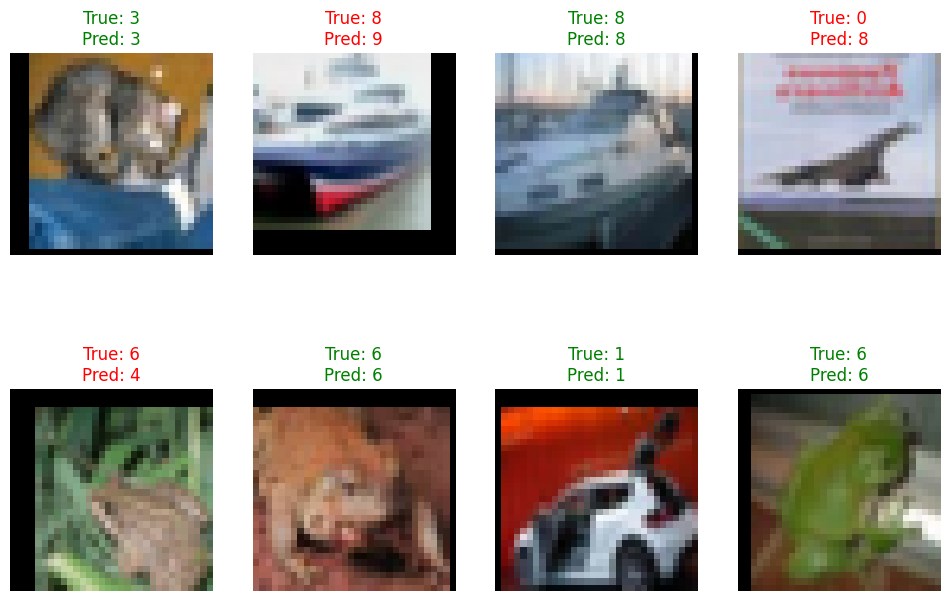

In [24]:
plt.figure(figsize=(12, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i].permute(1, 2, 0).cpu() * 0.5 + 0.5)  # Denormalize for display
    # Check if prediction matches the true label
    title_color = "green" if sample_labels[i] == preds[i] else "red"
    plt.title(f"True: {sample_labels[i]}\nPred: {preds[i]}", color=title_color)
    plt.axis("off")
plt.show()
